# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
from sklearn.model_selection import train_test_split
train_clfr, test_clfr = train_test_split(df_california, test_size=0.2, random_state=42)
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [5]:
#CONTOH PROGRAM AWAL.
import matplotlib.pyplot as plt
import seaborn as sns
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=10)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

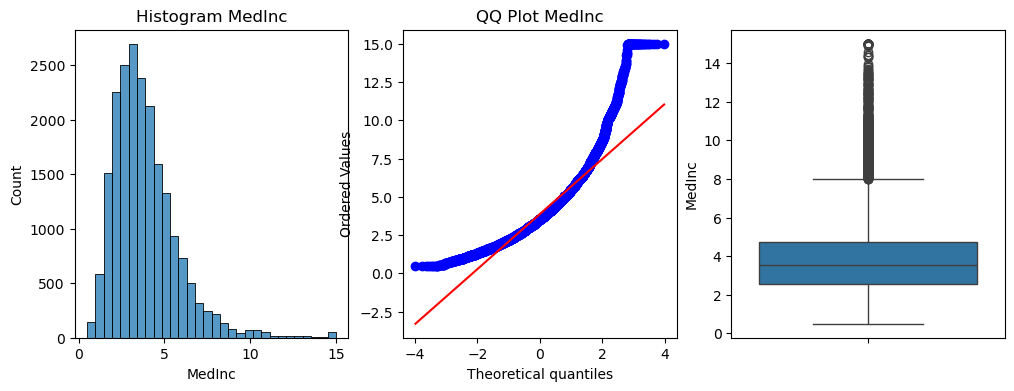

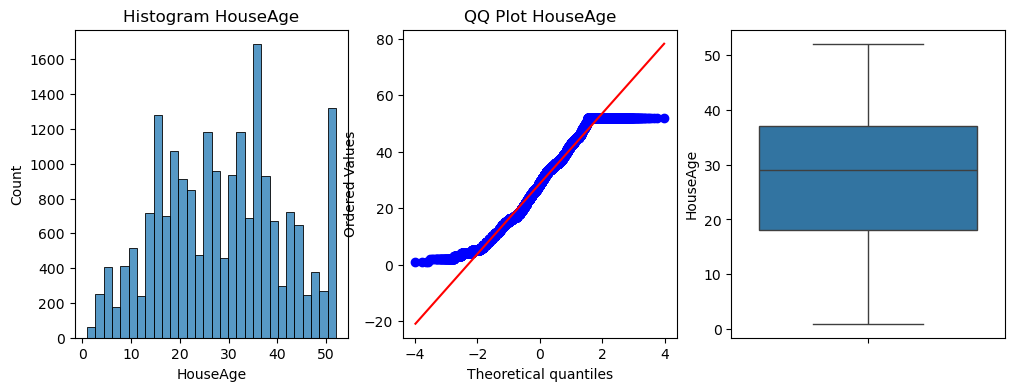

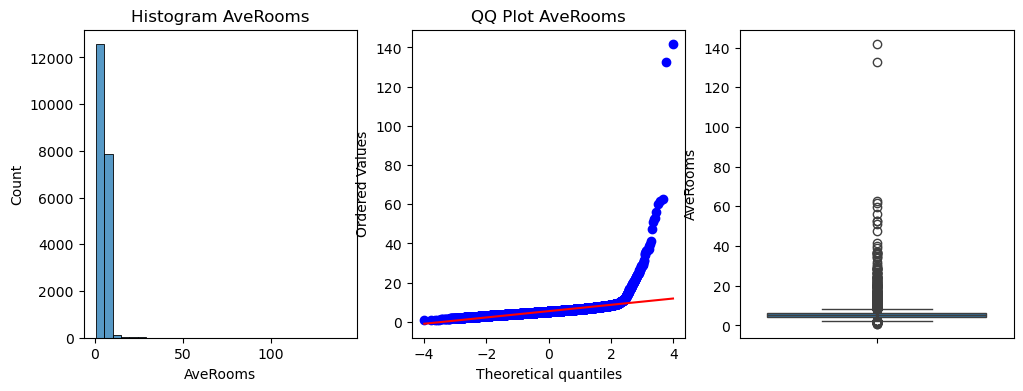

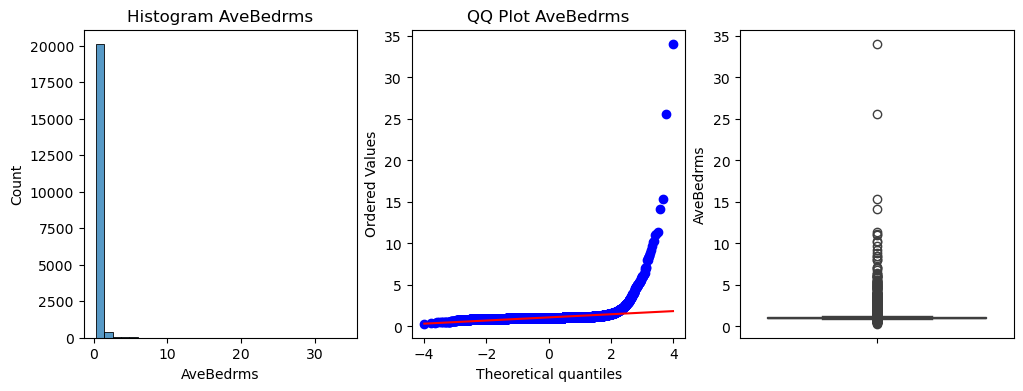

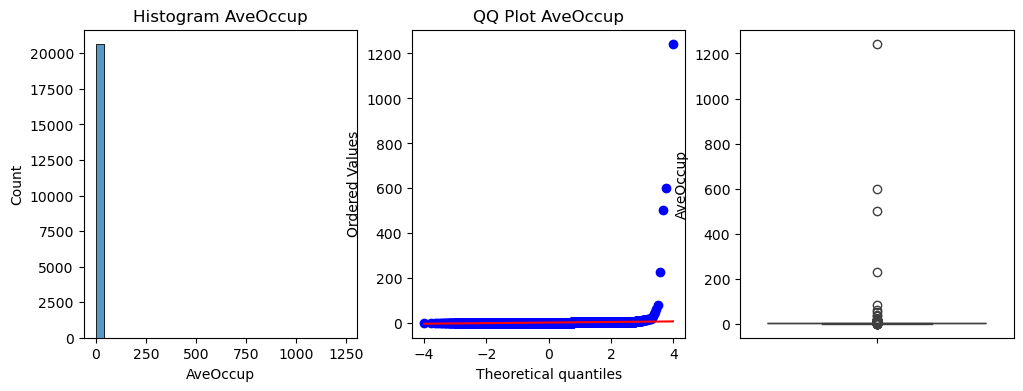

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#memanggil dataset
df = pd.read_csv('california_dataset.csv')

# daftar dataset yang ingin dicek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

#penggunaan (kolom_kolom) memudahkan pemanggil dalam banyak kolom, berbeda dengan 
#check check_plot(train_clfr, 'Population') yang hanya mamanggil satu kolom saja.

# looping untuk menampilkan distribusi dan outlier
# penggunaan (col) untuk looping
for col in kolom_kolom:

    plt.figure(figsize=(12,4))

    # histogram
    plt.subplot(1, 3, 1)
    #maksud kode program (df[col], bins=30) adalah memanggil variabel(dataset) serta melakukan looping sesuai dengan kolom yang sudah ditentukan, serta menentukan jumlah bins pada histogram sebanyak 30
    sns.histplot(df[col], bins=30)
    plt.title(f'Histogram {col}')

    # Q-Q plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot {col}')

    # boxplot
    #(baris, kolom, posisi) mendakan angka dari plt.subplot(1, 3, 3).
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[col])


### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [7]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali

import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

df_california = pd.read_csv('california_dataset.csv')


65.5 -10.5


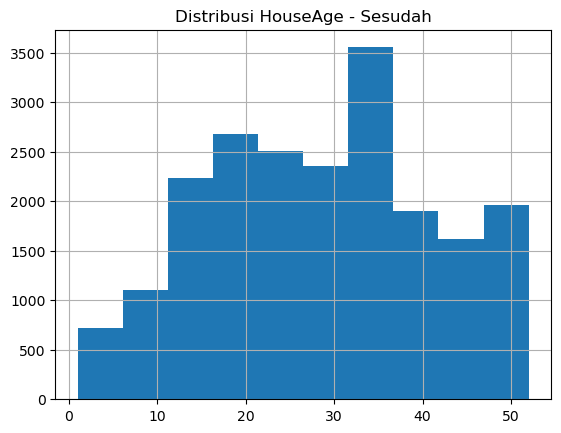

In [8]:
# Melakukan loop untuk mengecek distribusi tiap kolom
def find_outlier_boundary(df, variable):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)
    return upper_boundary, lower_boundary

HouseAge_upper_limit, HouseAge_lower_limit = find_outlier_boundary(df_california, 'HouseAge')
print(HouseAge_upper_limit, HouseAge_lower_limit)

# === 3. Handle outlier dengan capping ===
df_california['HouseAge'] = df_california['HouseAge'].clip(
    lower=HouseAge_lower_limit,
    upper=HouseAge_upper_limit
)

# === 4. Cek distribusi SESUDAH handling ===
df_california['HouseAge'].hist()
plt.title('Distribusi HouseAge - Sesudah')
plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [9]:
# Load ulang data (PENTING: harus dari awal)
df_company = pd.read_csv('company.csv')

# Cek missing value
print(df_company.isna().sum())

# Cek value counts tiap kolom
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts())
    print()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64
============= Revenue =================


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============= Size =================


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============= Rating =================


Rating
 3.5    58
-1.0    50
 4.0    41
 3.3    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.6    31
 3.4    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 4.3    14
 2.9    14
 4.6    12
 3.1    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.4     1
 2.3     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============= Headquarters =================


Headquarters
New York, NY                 33
-1                           31
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, United Kingdom    10
Cambridge, MA                10
Vienna, VA                    8
Denver, CO                    7
Herndon, VA                   7
Washington, DC                7
Woodbine, MD                  7
Saint Louis, MO               7
Bedford, MA                   7
Arlington, VA                 7
San Jose, CA                  7
San Antonio, TX               6
Mountain View, CA             6
Basel, Switzerland            6
San Rafael, CA                6
Chantilly, VA                 6
Fairfax, VA                   5
Houston, TX                   5
Pittsburgh, PA                5
Bethesda, MD                  5
Rockville, MD                 5
Los Angeles, CA               5
Springfield, MA            

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cek persentase nilai tidak valid
print(100 * len(df_company[df_company['Rating']==-1]) / len(df_company))
print(100 * len(df_company[df_company['Size'].isin(['-1','Unknown'])]) / len(df_company))
print(100 * len(df_company[df_company['Revenue'].isin(['-1','Unknown / Non-Applicable'])]) / len(df_company))

# Drop kolom Revenue
df_company = df_company.drop(columns=['Revenue'])

# Split
train_company, test_company = train_test_split(df_company, test_size=0.2, random_state=42)

# Handling missing value numerik dengan median
for col in train_company.select_dtypes(include='number').columns:
    median_val = train_company[col].median()
    train_company[col] = train_company[col].fillna(median_val)
    test_company[col] = test_company[col].fillna(median_val)

# Handling missing value kategorikal dengan modus
for col in train_company.select_dtypes(include='object').columns:
    mode_val = train_company[col].mode()[0]
    train_company[col] = train_company[col].fillna(mode_val)
    test_company[col] = test_company[col].fillna(mode_val)

print("Missing values train:", train_company.isnull().sum().sum())
print("Missing values test:", test_company.isnull().sum().sum())

7.440476190476191
6.5476190476190474
35.714285714285715
Missing values train: 0
Missing values test: 0


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [11]:
# Cek persentase missing value kolom Headquarters
persen_missing = 100 * df_company['Headquarters'].isna().sum() / len(df_company)
print(f"Persentase missing value Headquarters: {persen_missing:.2f}%")

# Cek jenis missing value
print("\nJenis missing value di kolom Headquarters:")
print(df_company['Headquarters'].value_counts(dropna=False))

Persentase missing value Headquarters: 0.00%

Jenis missing value di kolom Headquarters:
Headquarters
New York, NY                 33
-1                           31
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, United Kingdom    10
Cambridge, MA                10
Vienna, VA                    8
Denver, CO                    7
Herndon, VA                   7
Washington, DC                7
Woodbine, MD                  7
Saint Louis, MO               7
Bedford, MA                   7
Arlington, VA                 7
San Jose, CA                  7
San Antonio, TX               6
Mountain View, CA             6
Basel, Switzerland            6
San Rafael, CA                6
Chantilly, VA                 6
Fairfax, VA                   5
Houston, TX                   5
Pittsburgh, PA                5
Bethesda, MD                  5
Ro

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [12]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')


In [13]:
from sklearn.model_selection import train_test_split

# Splitting terlebih dahulu
X = df_churn.drop(columns=['Churn'])
y = df_churn['Churn'].map({'Yes': 1, 'No': 0})  # encode target juga

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. One Hot Encoding (OHE) - kolom gender
X_train = pd.get_dummies(X_train, columns=['gender'])
X_test = pd.get_dummies(X_test, columns=['gender'])

# Samakan kolom (antisipasi kolom tidak sama setelah OHE)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 2. Label Encoding - kolom Yes/No
label_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in label_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].map({'Yes': 1, 'No': 0})
        X_test[col] = X_test[col].map({'Yes': 1, 'No': 0})

# 3. Mean Encoding - kolom Contract
# Gabung X_train dengan y_train untuk hitung mean
train_temp = X_train.copy()
train_temp['Churn'] = y_train.values

mean_contract = train_temp.groupby('Contract')['Churn'].mean()
print("Mean Encoding Contract:\n", mean_contract)

X_train['Contract'] = X_train['Contract'].map(mean_contract)
X_test['Contract'] = X_test['Contract'].map(mean_contract)

print("\nEncoding selesai!")
print(X_train.dtypes)
print(X_train.head())

Mean Encoding Contract:
 Contract
Month-to-month    0.426533
One year          0.117987
Two year          0.028379
Name: Churn, dtype: float64

Encoding selesai!
customerID           object
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract            float64
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
gender_Female          bool
gender_Male            bool
dtype: object
      customerID  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
2142  4223-BKEOR              0        0           1      21             1   
1623  6035-RIIOM              0        0           0      54             1   
60

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [14]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder


In [15]:
from sklearn.preprocessing import LabelEncoder

# 1. Pilih kolom-kolom yang diminta
cols_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport', 
                  'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# 2. Ganti nilai 'No internet service' menjadi 'No', lalu validasi
for col in cols_to_encode:
    X_train[col] = X_train[col].replace('No internet service', 'No')
    X_test[col] = X_test[col].replace('No internet service', 'No')
    print(f"=== {col} ===")
    print(X_train[col].value_counts())
    print()

# 3. Label Encoding
le = LabelEncoder()

for col in cols_to_encode:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print("Label Encoding selesai!")
print(X_train[cols_to_encode].head())

=== StreamingMovies ===
StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64

=== StreamingTV ===
StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64

=== TechSupport ===
TechSupport
No     4005
Yes    1629
Name: count, dtype: int64

=== DeviceProtection ===
DeviceProtection
No     3703
Yes    1931
Name: count, dtype: int64

=== OnlineBackup ===
OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64

=== OnlineSecurity ===
OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64

=== MultipleLines ===
MultipleLines
No                  2685
Yes                 2397
No phone service     552
Name: count, dtype: int64

Label Encoding selesai!
      StreamingMovies  StreamingTV  TechSupport  DeviceProtection  \
2142                1            0            0                 1   
1623                1            1            0                 0   
6074                0            0            0                 0   
1362                0            0    

## Selesai :)